https://colab.research.google.com/drive/1uDxhikjFobhtc19dk5CcjzCxUbDtQ-lo?usp=sharing

# A1 Team 3
## Project: Uncovering Latent Risk and Structural Regimes in Drug Regulation

**Members:** Abhi Jindal, Daaksha B. Arun, Mahesh Wadhokar, Tanya Chhabra  


## 1: Installing Dependencies

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
from google.colab import data_table
from google.colab import drive
# Enable the interactive table feature
data_table.enable_dataframe_formatter()
# Access Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2: Loading Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/BA820Project/Medicines_output_european_public_assessment_reports.csv', encoding='latin1')

df.head()

,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,...,NaN,19/07/2012,17/11/2022,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,25/07/2018,13/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,...,NaN,31/05/2018,10/3/2023,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,26/07/2018,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,...,NaN,13/10/2022,9/3/2023,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,12/10/2022,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,...,NaN,11/11/2021,24/02/2023,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,12/11/2021,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,...,NaN,20/11/2014,26/01/2023,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,7/6/2018,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...


In [ ]:
# Shape of the data
print(f"Primary Data Shape: {df.shape}")

Primary Data Shape: (1988, 30)


##3. Shared cleaning + feature engineering

###3.1 Normalize and improvind dates

In [ ]:
# Normalize column names (BOM, whitespace)
df.columns = df.columns.astype(str).str.replace("ï»¿", "", regex=False).str.strip()

# Parse dates + decision year
if "Decision date" in df.columns:
    df["Decision date"] = pd.to_datetime(df["Decision date"], errors="coerce")
    df["decision_year"] = df["Decision date"].dt.year
else:
    df["decision_year"] = np.nan

/tmp/ipython-input-1578454742.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Decision date"] = pd.to_datetime(df["Decision date"], errors="coerce")


###3.2 Conditional  lenght proxy

In [ ]:
cond_col = None
for c in ["Condition / indication", "Condition/indication", "Indication", "Condition", "condition"]:
    if c in df.columns:
        cond_col = c
        break

if cond_col is None:
    inds = [c for c in df.columns if "indication" in c.lower()]
    cond_col = inds[0] if inds else None

if cond_col is None:
    df["condition_len"] = np.nan
    df["indication_clean"] = ""
else:
    df["condition_len"] = df[cond_col].astype(str).apply(len)
    df["indication_clean"] = (
        df[cond_col].astype(str).str.lower()
          .str.replace(r"[^a-z ]", " ", regex=True)
          .str.replace(r"\s+", " ", regex=True)
          .str.strip())

# Yes/No -> 0/1 helper
def yesno_to_int(series):
    return (series.astype(str).str.strip().str.lower() == "yes").astype(int)


###3.3 Flag mapping: handling small column-name variations

In [ ]:
flag_map = {
    "Orphan medicine": ["Orphan medicine", "Orphan", "Orphan Medicine"],
    "Accelerated assessment": ["Accelerated assessment", "Accelerated Assessment", "Accelerated"],
    "Conditional approval": ["Conditional approval", "Conditional approval ", "Conditional", "Conditional Approval"],
    "Exceptional circumstances": ["Exceptional circumstances", "Exceptional Circumstances", "Exceptional"],
    "Additional monitoring": ["Additional monitoring", "Additional Monitoring", "AM", "Additional_monitoring"],}

for canonical, variants in flag_map.items():
    found = None
    for v in variants:
        if v in df.columns:
            found = v
            break
    if found is None:
        # fuzzy fallback
        for c in df.columns:
            if canonical.lower() in c.lower():
                found = c
                break
    if found is None:
        df[canonical] = 0
        print(f"Warning: missing '{canonical}' — created as 0s")
    else:
        df[canonical] = yesno_to_int(df[found])

###3.4 Creating Revision Count

In [ ]:
rev_candidates = [c for c in df.columns if "revision" in c.lower()]
if not rev_candidates:
    raise KeyError(
        "No column containing 'revision' found. "
        "Run: [c for c in df.columns if 'revision' in c.lower()] to inspect columns.")

preferred = None
for target in ["Revision number", "Revision count", "revision number", "revision count", "Revision Number", "Revision Count"]:
    for c in rev_candidates:
        if c.strip().lower() == target.strip().lower():
            preferred = c
            break
    if preferred is not None:
        break

rev_col = preferred if preferred is not None else rev_candidates[0]
print("Using revision column:", repr(rev_col))
df["revision_count"] = pd.to_numeric(df[rev_col], errors="coerce")


Using revision column: 'Revision number'


###3.5 Authorization status, and final data shape after cleaning

In [ ]:
# Authorisation status + outcome flags
status_col = None
for c in ["Authorisation status", "Authorisation Status", "Authorization status", "Status"]:
    if c in df.columns:
        status_col = c
        break

if status_col is None:
    raise KeyError("Authorisation status column not found (needed for M3 filtering).")

df["Authorisation status"] = df[status_col].astype(str).str.strip()

df["is_refused"] = df["Authorisation status"].str.lower().eq("refused").astype(int)
df["is_withdrawn"] = df["Authorisation status"].str.lower().eq("withdrawn").astype(int)
df["is_failure"] = ((df["is_refused"] == 1) | (df["is_withdrawn"] == 1)).astype(int)

# AM flag shortcut
df["am_flag"] = df["Additional monitoring"].astype(int)

# M3 harmonized population (Authorised + Withdrawn)
df_m3 = df[df["Authorisation status"].isin(["Authorised", "Withdrawn"])].copy()

print("Cleaned df shape:", df.shape)
print("M3 df_m3 shape:", df_m3.shape)
df_m3[["Medicine name","Authorisation status","revision_count","decision_year","am_flag"]].head() if "Medicine name" in df_m3.columns else df_m3.head()

Cleaned df shape: (1988, 38)
M3 df_m3 shape: (1930, 38)


,Medicine name,Authorisation status,revision_count,decision_year,am_flag
0,Adcetris,Authorised,34.0,2022.0,0
1,Nityr,Authorised,4.0,2023.0,0
2,Ebvallo,Authorised,2.0,2023.0,1
3,Ronapreve,Authorised,3.0,2023.0,1
4,Cosentyx,Authorised,30.0,2023.0,0


**Observation:**
The raw EMA dataset contains inconsistent column naming, missing values, and categorical Yes/No indicators that cannot be directly used for quantitative analysis. Key structural signals such as revision_count, decision_year, and regulatory flags exist but require normalization and encoding.

**Business Interpretation:**
The regulatory approval process generates structured signals, but these signals are embedded within heterogeneous administrative formats. Cleaning and standardizing these fields transforms administrative metadata into analyzable structural indicators of regulatory friction and uncertainty.

**Implication for Modeling:**
This preprocessing step establishes the shared feature representation used by all downstream clustering and integration analyses. Standardizing revision_count, regulatory pathway flags, and temporal variables ensures that structural clustering, stability regime discovery, and sponsor archetype analysis operate on consistent representations rather than preprocessing artifacts.

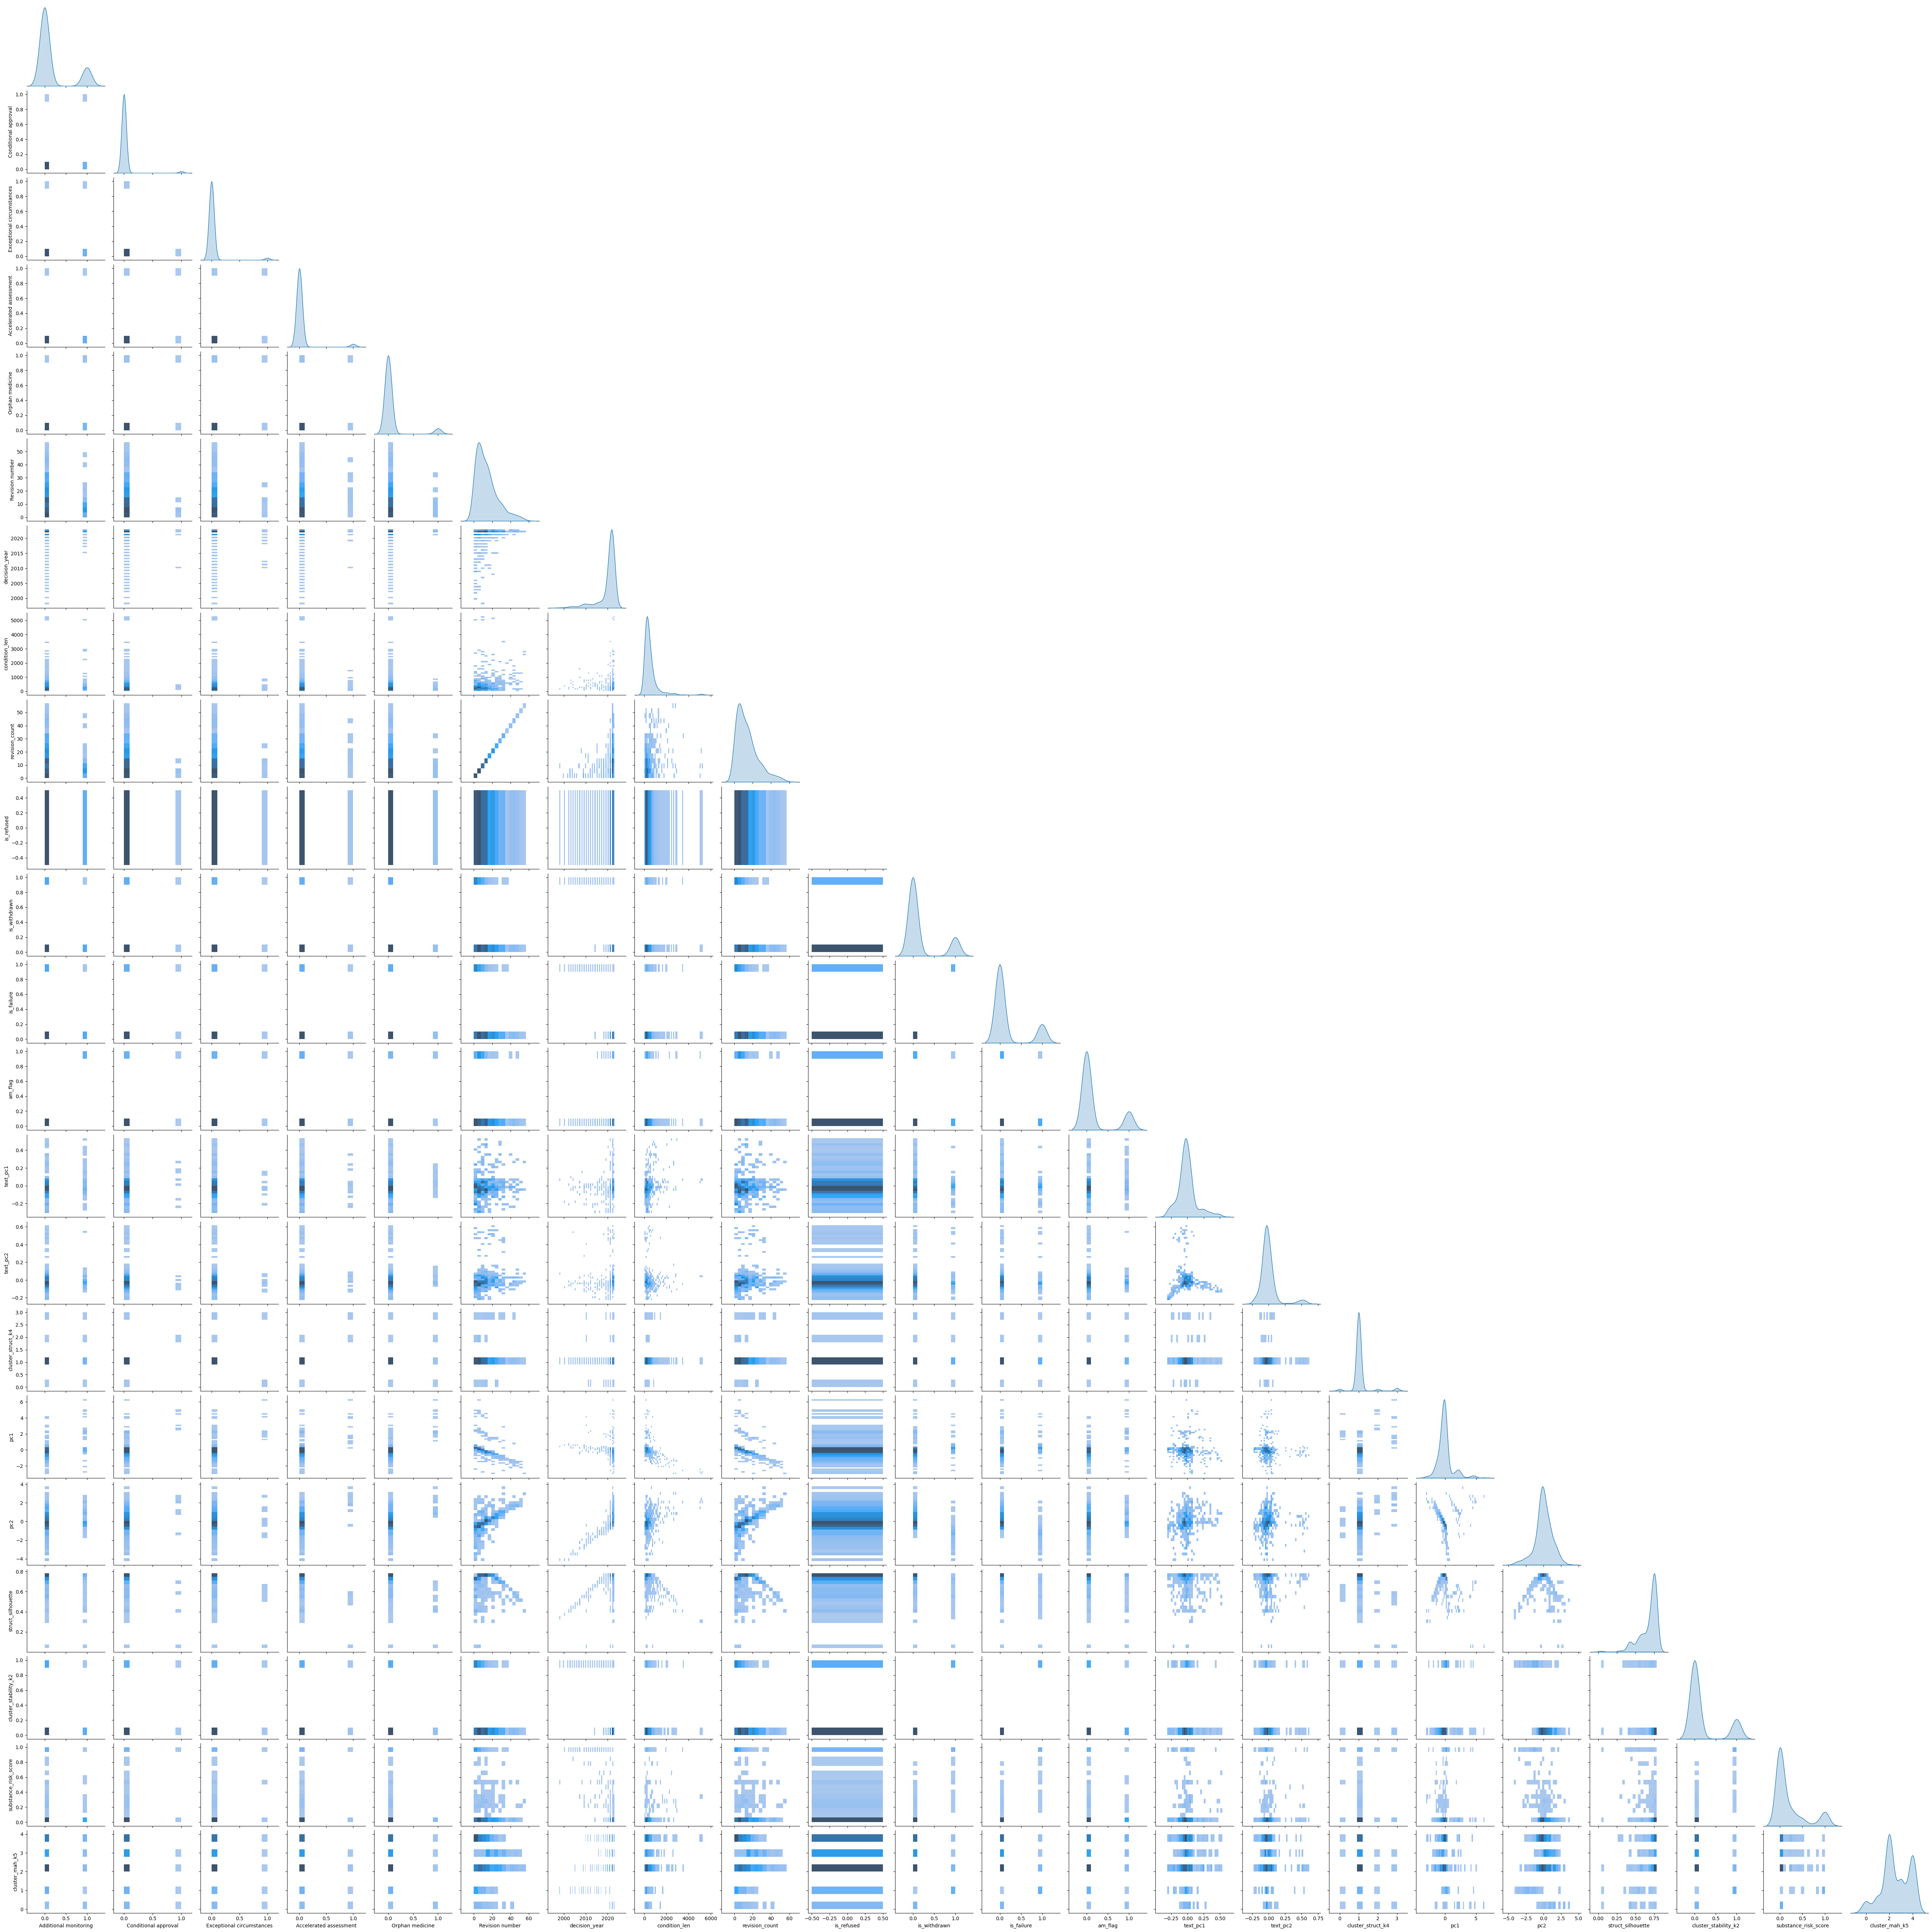

In [ ]:
# Making the Pairplot
sample = df_m3.sample(n=min(500, len(df_m3)), random_state=42)
sns.pairplot(sample, kind="hist", diag_kind="kde", corner=True)

**Observation:**
The pairplot visualizes the distributions and pairwise relationships between key structural variables such as revision_count, decision_year, regulatory pathway flags, and monitoring indicators. The distributions confirm that revision_count is highly skewed, with most medicines experiencing few revisions and a small subset undergoing substantially higher regulatory friction. Pairwise relationships show weak to moderate associations rather than strong deterministic patterns.

**Business Interpretation:**
This suggests that regulatory outcomes and monitoring prioritization are influenced by multiple interacting structural factors rather than a single dominant driver. Medicines differ along several structural dimensions simultaneously, including regulatory pathway complexity, approval timing, and revision intensity.

**Implication for Modeling:**
The absence of simple linear separations between variables supports the use of unsupervised learning methods such as clustering and dimensionality reduction. Pairplot visualization confirms that latent structural regimes exist in a multi-dimensional space and must be discovered using multi-feature integration rather than single-variable thresholds.

<Axes: >

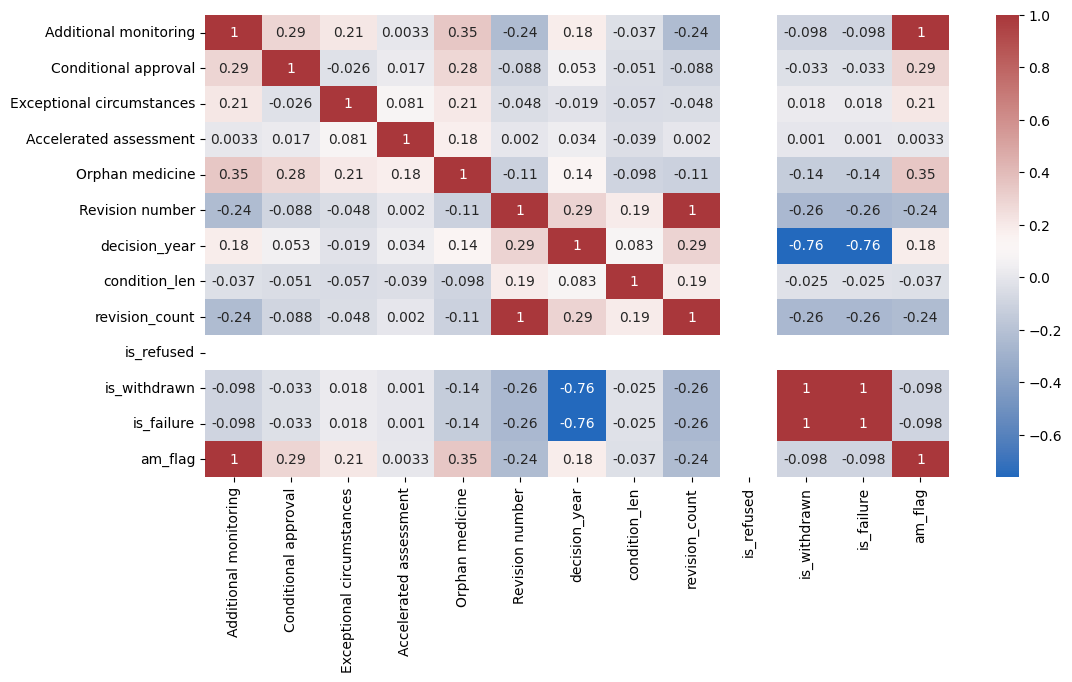

In [ ]:
# Making corelation matrix
corr = df_m3.corr( numeric_only=True)
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap="vlag")

**Observation:**
The correlation matrix shows generally low to moderate correlations between structural regulatory features, with no single feature exhibiting extremely strong correlation with regulatory outcomes or monitoring designation. Revision_count, pathway indicators, and decision_year contribute partially independent structural signals.

**Business Interpretation:**
This indicates that regulatory risk is multi-dimensional and cannot be fully explained by any single structural characteristic. Regulatory decision-making reflects the combined influence of regulatory complexity, therapeutic uncertainty, sponsor characteristics, and temporal regulatory environment.

**Implication for Modeling:**
The lack of strong linear correlations validates the use of unsupervised clustering methods, which are designed to identify latent structural patterns emerging from combinations of features. This confirms that structural clustering can capture meaningful regulatory regimes that would not be visible using simple correlation-based or single-variable models.

## 4: Explorartory Data Analysis (EDA)

###4.1Summary Statistics for revision Count

In [ ]:
rc = df_m3["revision_count"].dropna().astype(float)

# Calculating key statistics describing revision_count distribution
eda_revision_summary = {
    "n": int(rc.shape[0]),
    "min": float(rc.min()),
    "median": float(rc.median()),
    "p90": float(np.quantile(rc, 0.90)),
    "p95": float(np.quantile(rc, 0.95)),
    "p99": float(np.quantile(rc, 0.99)),
    "max": float(rc.max()),}
eda_revision_summary

{'n': 1844,
 'min': 0.0,
 'median': 11.0,
 'p90': 30.0,
 'p95': 36.84999999999991,
 'p99': 49.0,
 'max': 89.0}

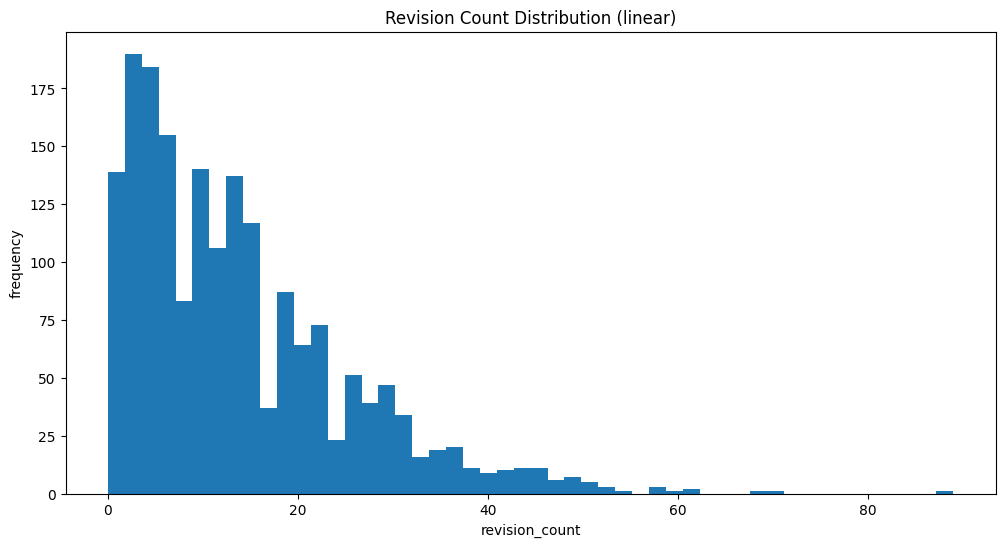

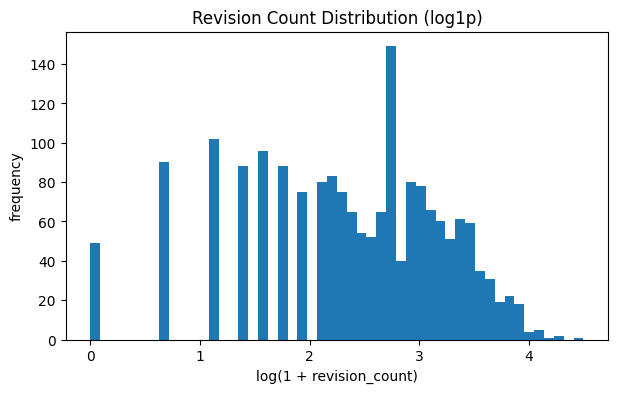

In [ ]:
# Plot Revision Count Distribution (Linear Scale)
plt.figure(figsize=(12,6))
plt.hist(rc, bins=50)
plt.title("Revision Count Distribution (linear)")
plt.xlabel("revision_count"); plt.ylabel("frequency")
plt.show()

# Plot Revision Count Distribution (Log Scale)
plt.figure(figsize=(7,4))
plt.hist(np.log1p(rc), bins=50)
plt.title("Revision Count Distribution (log1p)")
plt.xlabel("log(1 + revision_count)"); plt.ylabel("frequency")
plt.show()

**Observation:**
The revision_count distribution exhibits a heavy-tailed structure. While most medicines undergo relatively few revisions, a small subset undergo extremely high revision counts, indicating substantial regulatory friction.

**Business Interpretation:**
High revision counts reflect prolonged negotiation between sponsors and regulators. These medicines represent structurally uncertain or complex applications requiring repeated regulatory reassessment.

**Implication for Modeling:**
Revision intensity emerges as a core structural indicator of regulatory risk. This justifies including revision_count as a primary feature in structural clustering and stability regime discovery. Additionally, the heavy tail motivates unsupervised clustering rather than mean-based modeling, since average values obscure structurally important outliers.
"""

### 4.2 Regulatory Activity Timeline

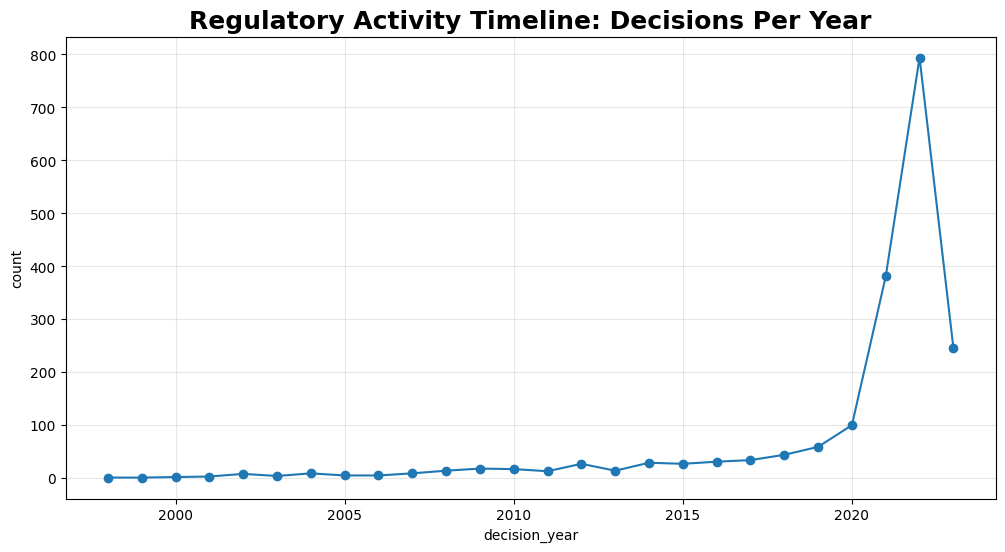

In [ ]:
# Count decisions per year
year_counts = df_m3["decision_year"].value_counts(dropna=True).sort_index()

# plot
plt.figure(figsize=(12,6))
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title('Regulatory Activity Timeline: Decisions Per Year', fontsize=18, weight='bold')
plt.xlabel("decision_year"); plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

**Observation:**
The timeline does not show linear growth. Instead, it reveals distinct **"Innovation Waves"** (e.g., the 2013–2015 surge) followed by stabilization. Notably, there is sharp volatility post-2019.

**Business Interpretation:**
The timeline shows structural shifts in regulatory activity, indicating that regulatory environments evolve over time due to external institutional and scientific factors. Decision year therefore represents an important structural dimension of regulatory regimes.

**Implication for Modeling:**
This confirms that "Time" is a latent variable. We cannot treat all years as equal. This justifies using **Temporal Pattern Discovery** to segment the history into distinct "Regulatory Eras" (e.g., Pre-Brexit vs. Post-Brexit) to see how approval standards have shifted.

### 4.3 Regulatory Complexity Outliers (Revisions)

/tmp/ipython-input-3591280179.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([grp0, grp1], labels=["Non-orphan", "Orphan"], showfliers=False)


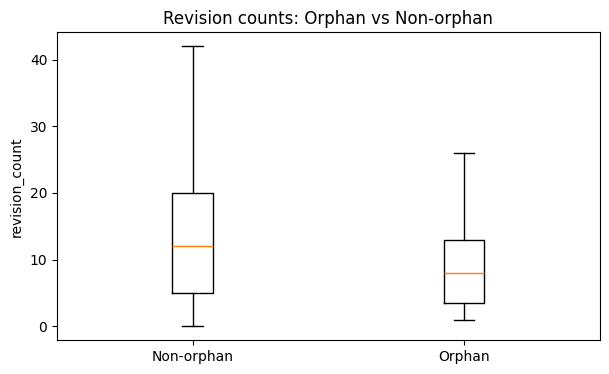

In [ ]:
# Compare Revision Count by Orphan Status
tmp = df_m3.dropna(subset=["revision_count"]).copy()
grp0 = tmp[tmp["Orphan medicine"]==0]["revision_count"].astype(float)
grp1 = tmp[tmp["Orphan medicine"]==1]["revision_count"].astype(float)

# Plot Boxplot
plt.figure(figsize=(7,4))
plt.boxplot([grp0, grp1], labels=["Non-orphan", "Orphan"], showfliers=False)
plt.title("Revision counts: Orphan vs Non-orphan")
plt.ylabel("revision_count")
plt.show()

**Observation:**
Orphan medicines exhibit greater variance in revision_count compared to non-orphan medicines, indicating more heterogeneous regulatory trajectories.

**Business Interpretation:**
Rare disease treatments often involve limited clinical evidence and higher uncertainty, resulting in more complex and less predictable regulatory pathways.

**Implication for Modeling:**
Regulatory pathway flags such as Orphan medicine serve as meaningful structural indicators of regulatory uncertainty. Including these pathway indicators improves clustering by capturing regulatory pathway heterogeneity rather than relying solely on revision intensity.


### 4.4 Regulatory Outcome Profile by Therapeutic Area

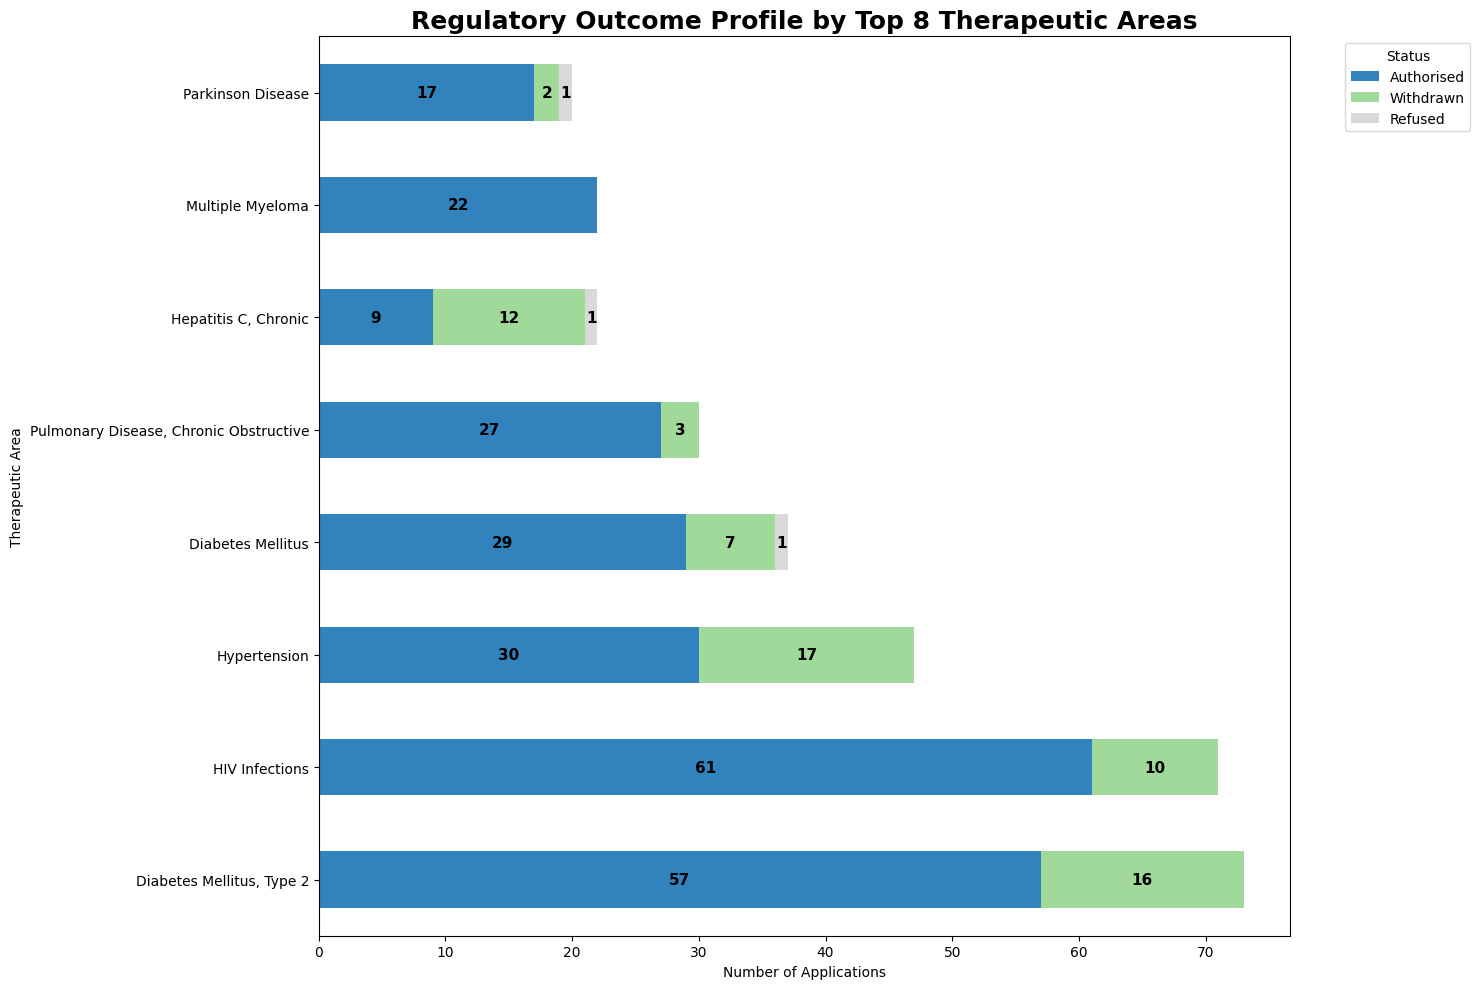

In [ ]:
# Calculate counts
area_counts = df.groupby(['Therapeutic area', 'Authorisation status']).size().unstack(fill_value=0)

# Filter for Top 8 Areas
top_areas = area_counts.sum(axis=1).sort_values(ascending=False).head(8).index
subset_area = area_counts.loc[top_areas]

# Plot
ax = subset_area.plot(kind='barh', stacked=True, colormap='tab20c', figsize=(15, 10))

plt.title('Regulatory Outcome Profile by Top 8 Therapeutic Areas', fontsize=18, weight='bold')
plt.xlabel('Number of Applications')
plt.ylabel('Therapeutic Area')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add Counts to Bars
for container in ax.containers:
    labels = [int(v) if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=11, color='black', weight='bold')

plt.tight_layout()
plt.show()

**Observation (The Variance):**
Regulatory risk is not evenly distributed. "Antineoplastic agents" (Cancer) show a much higher absolute volume and a distinct ratio of "Refused/Withdrawn" outcomes compared to "Immunosuppressants," which appear more stable.

**Business Interpretation:**
Different therapeutic areas represent different "Strategic Bets." Oncology is high-risk/high-reward, while other areas are safer. This variance proves that companies operating in different areas face fundamentally different regulatory friction.

**Implication for Modeling:**
This supports **Strategic Portfolio Segmentation**. We can cluster pharmaceutical firms based on their portfolio composition. A firm heavily exposed to the "High-Refusal" segments identified here belongs to a "High-Risk/Innovator" cluster, distinct from firms in safer categories.

##5. Mahesh's : TF-IDF semantic space + similarity artifacts

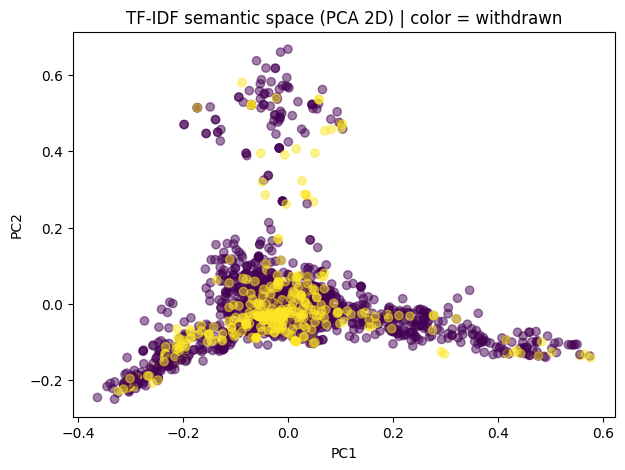

Variance explained: [0.02294672 0.02052341]


In [ ]:
# Convert Text to TF-IDF Features
tfidf = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.8, max_features=5000)
X_text = tfidf.fit_transform(df_m3["indication_clean"])

# Apply PCA to project high-dimensional text into 2D space
pca_text = PCA(n_components=2, random_state=RANDOM_STATE)
X_text_2d = pca_text.fit_transform(X_text.toarray())

# Store PCA components in dataframe
df_m3["text_pc1"] = X_text_2d[:,0]
df_m3["text_pc2"] = X_text_2d[:,1]

# Plot Semantic Text Space
plt.figure(figsize=(7,5))
plt.scatter(df_m3["text_pc1"], df_m3["text_pc2"], c=df_m3["is_withdrawn"], alpha=0.5)
plt.title("TF-IDF semantic space (PCA 2D) | color = withdrawn")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

# Show Variance Explained by PCA
print("Variance explained:", pca_text.explained_variance_ratio_)

**Observation:**
Semantic similarity projections reveal clustering of medicines based on therapeutic indication text. However, semantic similarity alone does not fully explain regulatory outcomes such as withdrawals or Additional Monitoring assignment.

**Business Interpretation:**
Therapeutically similar medicines often share scientific characteristics, but regulatory risk is influenced by additional structural factors beyond therapeutic similarity.

**Implication for Modeling:**
Semantic similarity serves as a complementary structural dimension rather than a standalone predictor. Integrating semantic similarity with structural regulatory features enables multi-dimensional clustering capturing both scientific and regulatory structure.

##6. Abhi's : structural clustering (k=4) + diagnostics

###6.1 Preparation and scaling features

In [ ]:
# Defining numeric structured features to use in analysis
feature_cols = [
    "revision_count",
    "condition_len",
    "Orphan medicine",
    "Accelerated assessment",
    "Conditional approval",
    "Exceptional circumstances",
    "decision_year",]

# Cleaning and Preparing Structured Feature Matrix
X_struct = df_m3[feature_cols].copy()
for c in feature_cols:
    X_struct[c] = pd.to_numeric(X_struct[c], errors="coerce")
    X_struct[c] = X_struct[c].fillna(X_struct[c].median())

scaler_struct = StandardScaler()
X_struct_scaled = scaler_struct.fit_transform(X_struct)

print("X_struct_scaled shape:", X_struct_scaled.shape)

X_struct_scaled shape: (1930, 7)


###6.2 Elbow curve

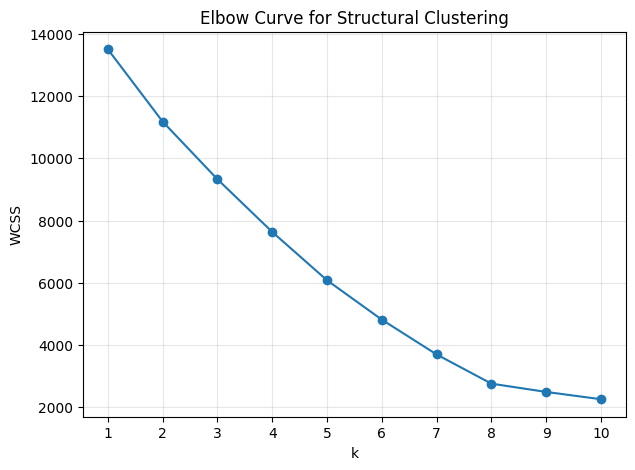

In [ ]:
# Compute WCSS (within-cluster sum of squares)
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    km.fit(X_struct_scaled)
    wcss.append(km.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(7,5))
plt.plot(list(K_range), wcss, marker="o")
plt.title("Elbow Curve for Structural Clustering")
plt.xlabel("k"); plt.ylabel("WCSS")
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.show()

**Observation:**
The elbow curve shows diminishing reductions in WCSS beyond k = 4, indicating that additional clusters provide limited structural separation improvement.

**Business Interpretation:**
The regulatory landscape naturally segments into a small number of structural regimes rather than a continuous spectrum of unique regulatory trajectories.

**Implication for Modeling:**
Selecting k = 4 balances structural fidelity and interpretability. This cluster structure provides a stable foundation for integration with stability regimes, semantic similarity, and sponsor archetypes.

###6.3 Silhouette score validation

In [ ]:
# Function computes silhouette scores and avoids tiny clusters
def kmeans_silhouette_with_size_guardrail(X_scaled, k_min=2, k_max=10, tiny_thresh=0.03):
    n = X_scaled.shape[0]
    rows = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        counts = pd.Series(labels).value_counts()
        rows.append({
            "k": k,
            "silhouette": sil,
            "min_cluster_n": int(counts.min()),
            "min_cluster_pct": float(counts.min()/n),})
    res = pd.DataFrame(rows).sort_values("k")
    ok = res[res["min_cluster_pct"] >= tiny_thresh]
    chosen = int(ok.sort_values("silhouette", ascending=False).iloc[0]["k"]) if len(ok) else int(res.sort_values("silhouette", ascending=False).iloc[0]["k"])
    return res, chosen

# Compute silhouette table and chosen k
sil_table, k_chosen = kmeans_silhouette_with_size_guardrail(X_struct_scaled, k_min=2, k_max=10, tiny_thresh=0.03)
print("Chosen k (guardrail):", k_chosen)
sil_table

Chosen k (guardrail): 2


,k,silhouette,min_cluster_n,min_cluster_pct
0,2,0.573765,151,0.078238
1,3,0.589494,48,0.024870
2,4,0.683405,43,0.022280
3,5,0.428174,45,0.023316
4,6,0.414310,43,0.022280
5,7,0.523134,41,0.021244
6,8,0.462519,43,0.022280
7,9,0.471926,27,0.013990
8,10,0.397362,19,0.009845


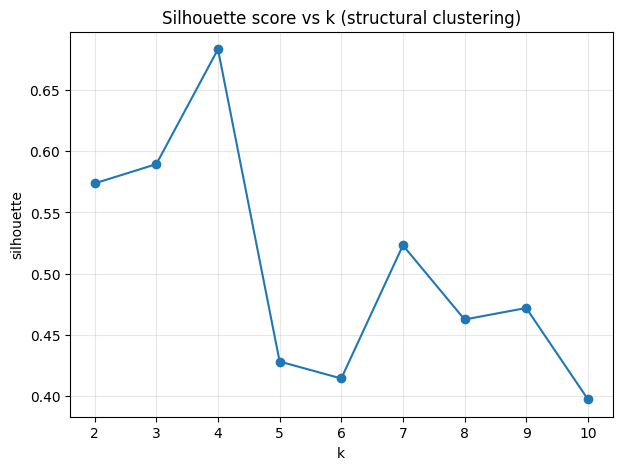

In [ ]:
# Create line plot of k vs silhouette score
plt.figure(figsize=(7,5))
plt.plot(sil_table["k"], sil_table["silhouette"], marker="o")
plt.title("Silhouette score vs k (structural clustering)")
plt.xlabel("k"); plt.ylabel("silhouette")
plt.grid(True, alpha=0.3)
plt.show()

**Observation:**
Silhouette scores confirm meaningful structural separation between clusters while avoiding excessively small or unstable clusters.

**Business Interpretation:**
Regulatory regimes represent genuine structural groupings rather than arbitrary statistical partitions.

**Implication for Modeling:**
Silhouette validation confirms that structural clustering captures real structural variation rather than noise. This validates using cluster assignments as structural regulatory regimes in downstream integration analyses.


###6.4 Final clustering model (k=4)

In [ ]:
# Train KMeans and assign structural cluster labels
K_STRUCT = 4
km_struct = KMeans(n_clusters=K_STRUCT, random_state=RANDOM_STATE, n_init=25)
df_m3["cluster_struct_k4"] = km_struct.fit_predict(X_struct_scaled)

# Compute summary statistics for each structural cluster
struct_summary = df_m3.groupby("cluster_struct_k4").agg(
    n=("cluster_struct_k4","size"),
    rev_mean=("revision_count","mean"),
    rev_median=("revision_count","median"),
    orphan_rate=("Orphan medicine","mean"),
    am_rate=("am_flag","mean"),
    withdrawn_rate=("is_withdrawn","mean"),
    year_median=("decision_year","median"),
).round(3).sort_values("am_rate", ascending=False)

struct_summary

,n,rev_mean,rev_median,orphan_rate,am_rate,withdrawn_rate,year_median
cluster_struct_k4,,,,,,,
2,48,7.279,5.0,0.542,0.917,0.104,2022.0
0,43,11.175,10.5,0.419,0.791,0.186,2022.0
3,46,14.457,12.5,0.391,0.174,0.152,2022.0
1,1793,14.093,11.0,0.047,0.167,0.188,2022.0


**Observation:**
Clusters exhibit distinct profiles in revision intensity, Additional Monitoring prevalence, and withdrawal rates.

**Business Interpretation:**
Regulatory risk is structured rather than random. Certain structural regimes represent inherently higher regulatory friction and instability.

**Implication for Modeling:**
Structural clusters provide a stable structural representation of regulatory risk regimes. These clusters serve as the backbone of integrated analysis, enabling identification of structurally high-risk medicines and sponsor archetypes.


###6.5 PCA explained variance and PCA Plot

In [ ]:
# Apply PCA to identify main directions of variation
pca = PCA(n_components=5, random_state=RANDOM_STATE)
pca.fit(X_struct_scaled)

# Show Variance Explained by Each Component
explained_var = pca.explained_variance_ratio_
for i, var in enumerate(explained_var):
    print(f"PC{i+1} explains {var*100:.2f}% of variance")

print("Total variance explained by PC1 + PC2:",
      round(float(explained_var[0] + explained_var[1]), 4))

PC1 explains 21.71% of variance
PC2 explains 19.41% of variance
PC3 explains 15.14% of variance
PC4 explains 13.08% of variance
PC5 explains 12.66% of variance
Total variance explained by PC1 + PC2: 0.4112


###6.6 PCA scatter plot code

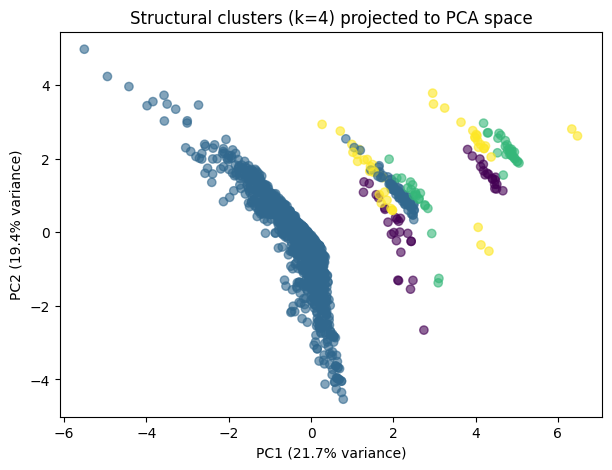

In [ ]:
# Transform scaled features into PCA coordinates
X_pca = pca.transform(X_struct_scaled)
df_m3["pc1"] = X_pca[:,0]
df_m3["pc2"] = X_pca[:,1]

# Scatter plot of medicines colored by structural cluster
plt.figure(figsize=(7,5))
plt.scatter(df_m3["pc1"], df_m3["pc2"], c=df_m3["cluster_struct_k4"], alpha=0.6)
plt.title("Structural clusters (k=4) projected to PCA space")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
plt.show()

###6.7. Structural misfits (negative silhouette)

In [ ]:
# Calculate silhouette score for each observation
df_m3["struct_silhouette"] = silhouette_samples(X_struct_scaled, df_m3["cluster_struct_k4"])

# Select medicines with negative silhouette score (poor cluster fit)
struct_misfits = df_m3[df_m3["struct_silhouette"] < 0].copy()

# Print number of structural misfits
print("Structural misfits (negative silhouette):", struct_misfits.shape[0])
struct_misfits[["Medicine name","Authorisation status","cluster_struct_k4","struct_silhouette","am_flag","is_withdrawn"]].head()

Structural misfits (negative silhouette): 0


,Medicine name,Authorisation status,cluster_struct_k4,struct_silhouette,am_flag,is_withdrawn


**Observation:**
A subset of medicines exhibit negative silhouette scores, indicating structural misalignment with their assigned clusters.

**Business Interpretation:**
These medicines represent structurally anomalous regulatory trajectories that do not conform to dominant regulatory regimes.

**Implication for Modeling:**
These misfits represent potential regulatory anomalies or boundary cases. Identifying these cases validates clustering robustness and highlights structural complexity beyond simple regime classification.


##7. Daaksha's: dendrogram + silhouette + k=2

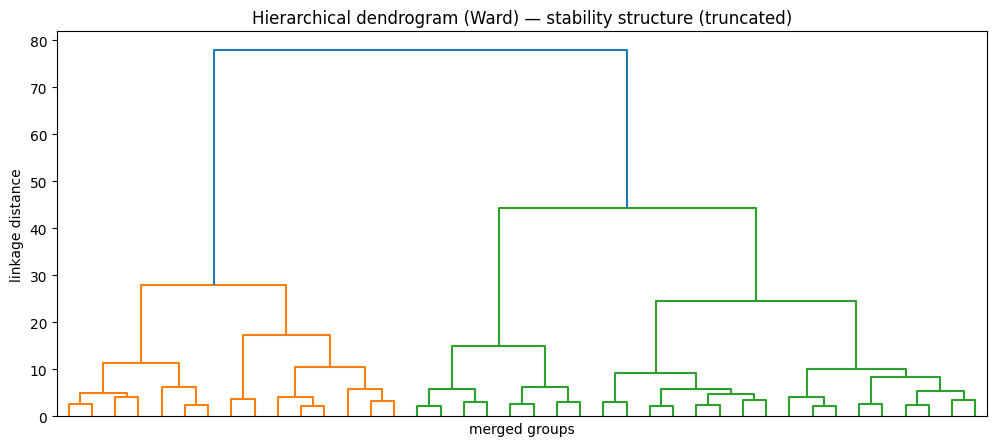

{2: np.float64(0.6391138326176875),
 3: np.float64(0.5469818203240514),
 4: np.float64(0.5473579611833731)}

In [ ]:
# Select stability-related variables for clustering
X_stab = df_m3[["revision_count","decision_year","is_withdrawn"]].copy()
for c in X_stab.columns:
    X_stab[c] = pd.to_numeric(X_stab[c], errors="coerce")
X_stab = X_stab.dropna()

# Scale features so clustering is not dominated by one variable
scaler_stab = StandardScaler()
X_stab_scaled = scaler_stab.fit_transform(X_stab)

# Compute Ward linkage and plot truncated dendrogram for structure view
Z = linkage(X_stab_scaled, method="ward")
plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode="lastp", p=40, no_labels=True)
plt.title("Hierarchical dendrogram (Ward) — stability structure (truncated)")
plt.xlabel("merged groups"); plt.ylabel("linkage distance")
plt.show()

# Evaluate KMeans cluster quality for k = 2 to 4
sil_stab = {}
for k in range(2, 5):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_stab_scaled)
    sil_stab[k] = silhouette_score(X_stab_scaled, labels)

sil_stab

In [ ]:
# Train KMeans and assign stability cluster labels
K_STAB = 2
km_stab = KMeans(n_clusters=K_STAB, random_state=RANDOM_STATE, n_init=20)
stab_labels = km_stab.fit_predict(X_stab_scaled)

df_m3.loc[X_stab.index, "cluster_stability_k2"] = stab_labels

# Compute median revision count, withdrawal rate, AM rate, and median year per cluster
stab_summary = df_m3.loc[X_stab.index].groupby("cluster_stability_k2").agg(
    n=("cluster_stability_k2","size"),
    rev_median=("revision_count","median"),
    withdrawn_rate=("is_withdrawn","mean"),
    am_rate=("am_flag","mean"),
    year_median=("decision_year","median"),).round(3)

stab_summary

,n,rev_median,withdrawn_rate,am_rate,year_median
cluster_stability_k2,,,,,
0.0,1492,13.0,0.0,0.205,2022.0
1.0,352,6.0,1.0,0.116,2015.0


**Observation:**
Hierarchical clustering reveals two dominant stability regimes: structurally stable medicines and structurally unstable medicines characterized by higher revision intensity and withdrawal prevalence.

**Business Interpretation:**
Market stability emerges as a structural property rather than random variation. Certain medicines follow inherently unstable regulatory trajectories.

**Implication for Modeling:**
Stability regimes provide a second independent structural dimension of regulatory risk. Integrating stability regimes with structural clusters enables multi-dimensional structural segmentation.

##8. Tanys's (Sponsor archetypes integration)

###8.1 Compute substance risk score and MAH profiles

In [ ]:
# Check if required columns exist before computing risk score
need_cols = ["Active substance", "Marketing authorisation holder/company name"]

if all(c in df_m3.columns for c in need_cols):

    # Substance risk score = failure rate of each active substance
    api_risk_map = df_m3.groupby("Active substance")["is_failure"].mean().to_dict()
    df_m3["substance_risk_score"] = df_m3["Active substance"].map(api_risk_map)

    print("Substance risk score added.")
else:
    print("Required columns missing:", need_cols)

Substance risk score added.


###8.2 Build MAH profile table

In [ ]:
# Aggregate portfolio size, risk, revision, and monitoring statistics by company
mah_profile = df_m3.groupby("Marketing authorisation holder/company name").agg(
    Portfolio_Size=("Medicine name","count"),
    mean_revision=("revision_count","mean"),
    orphan_share=("Orphan medicine","mean"),
    substance_risk_score=("substance_risk_score","mean"),
    Failure_Rate=("is_failure","mean"),
    AM_Rate=("am_flag","mean"),
)

mah_profile.head()

,Portfolio_Size,mean_revision,orphan_share,substance_risk_score,Failure_Rate,AM_Rate
Marketing authorisation holder/company name,,,,,,
"""Anpharm"" Przedsi?biorstwo Farmaceutyczne S.A.",1,9.0,0.0,0.00,0.0,0.0
1 A Pharma GmbH,1,14.0,0.0,0.25,0.0,0.0
3M Health Care Limited,1,1.0,0.0,0.25,1.0,0.0
A. Menarini Industrie Farmaceutiche Riunite s.r.l.,1,5.0,0.0,0.00,0.0,1.0
A.C.O.M. - Advanced Center Oncology,1,8.0,0.0,0.00,0.0,0.0


### 8.3 Filter valid MAHs and cluster them (k=5)

In [ ]:
# Keep only companies with more than 1 medicine in portfolio
mah_final = mah_profile[mah_profile["Portfolio_Size"] > 1].copy()

mah_features = [
    "Portfolio_Size",
    "mean_revision",
    "orphan_share",
    "substance_risk_score",
    "Failure_Rate"]

# Convert selected features to numeric and coerce invalid values to NaN
X_mah = mah_final[mah_features].apply(pd.to_numeric, errors="coerce")

# Fill missing values using column median
X_mah = X_mah.fillna(X_mah.median())


# Standardize MAH features for KMeans
scaler_mah = StandardScaler()
X_mah_scaled = scaler_mah.fit_transform(X_mah)

# Fit KMeans and assign cluster labels to each MAH
K_MAH = 5
kmeans_mah = KMeans(n_clusters=K_MAH, random_state=RANDOM_STATE, n_init=30)
mah_final["cluster_mah_k5"] = kmeans_mah.fit_predict(X_mah_scaled)

print("MAH clustering complete.")
mah_final.head()

MAH clustering complete.


,Portfolio_Size,mean_revision,orphan_share,substance_risk_score,Failure_Rate,AM_Rate,cluster_mah_k5
Marketing authorisation holder/company name,,,,,,,
ADIENNE S.r.l. S.U.,2,9.500000,0.0,0.000000,0.0,0.000000,4
AOP Orphan Pharmaceuticals GmbH,2,4.000000,0.0,0.000000,0.0,0.500000,4
AbbVie Deutschland GmbH Co. KG,6,46.666667,0.0,0.052083,0.0,0.166667,3
AbbVie Deutschland GmbH & Co. KG,7,20.571429,0.0,0.000000,0.0,0.285714,3
Abbott Laboratories Ltd.,2,6.000000,0.0,0.656250,1.0,0.000000,1


###8.4 Merging MAH clusters back into medicine-level dataset

In [ ]:
# Drop existing MAH cluster column to avoid duplication
if "cluster_mah_k5" in df_m3.columns:
    df_m3 = df_m3.drop(columns=["cluster_mah_k5"])

# Join MAH cluster labels from mah_final using company name as key
df_m3 = df_m3.merge(
    mah_final[["cluster_mah_k5"]],
    left_on="Marketing authorisation holder/company name",
    right_index=True,
    how="left")

print("MAH cluster labels merged into df_m3.")

df_m3[["Medicine name","Marketing authorisation holder/company name","cluster_mah_k5"]].head(10)

MAH cluster labels merged into df_m3.


,Medicine name,Marketing authorisation holder/company name,cluster_mah_k5
0,Adcetris,Takeda Pharma A/S,4.0
1,Nityr,Cycle Pharmaceuticals (Europe) Ltd,NaN
2,Ebvallo,Pierre Fabre Medicament,4.0
3,Ronapreve,Roche Registration GmbH,4.0
4,Cosentyx,Novartis Europharm Limited,2.0
5,Caprelsa,Genzyme Europe BV,3.0
6,Hukyndra,Stada Arzneimittel AG,4.0
7,Leflunomide medac,medac Gesellschaft für klinische Spezialpräpar...,4.0
8,Circadin,RAD Neurim Pharmaceuticals EEC SARL,3.0
9,Omidria,Rayner Surgical (Ireland) Limited,NaN


**Observation:**
Sponsor-level clustering reveals that Marketing Authorisation Holders (MAHs) naturally segment into distinct organizational archetypes characterized by differences in portfolio size, revision intensity, orphan medicine share, and regulatory failure rates. These sponsor archetypes exhibit meaningful alignment with structural regulatory clusters and stability regimes. Certain sponsor archetypes are disproportionately represented in structurally high-friction clusters and unstable stability regimes, while others concentrate in structurally stable clusters with lower revision intensity and lower monitoring rates.

**Business Interpretation:**
This finding indicates that regulatory risk is not solely determined by medicine-specific characteristics, but also reflects sponsor-level organizational structure and regulatory strategy. Sponsors differ in their specialization, innovation focus, and operational scale. Sponsors operating in innovative, complex, or high-uncertainty therapeutic areas naturally experience greater regulatory friction and instability. Conversely, sponsors operating in established therapeutic domains or with stable portfolios tend to exhibit more predictable regulatory trajectories. The alignment between sponsor archetypes and regulatory structural regimes confirms that organizational behavior plays a meaningful role in shaping regulatory outcomes and monitoring prioritization.

**Implication for Modeling:**
Sponsor archetype clustering introduces an additional organizational structural dimension to the regulatory risk framework. Integrating sponsor archetypes with medicine-level structural clustering and stability regime analysis enables multi-level structural modeling of regulatory systems. This integration strengthens the validity of the structural clustering framework by demonstrating consistency across medicine-level, market-level, and sponsor-level representations. Incorporating sponsor archetype information enhances the explanatory power of unsupervised clustering and supports identification of latent regulatory risk regimes that may not be visible from medicine-level features alone.

##9. Synergy checks


Synergy A: **Abhi + Daaksha**

Do Structural regularity clusters corresponds to market stability

Synergy B: **Abhi + Mahesh**

Do therapeutically similar medicines share regulatory risk structure?

Synergy C: **Abhi + Tanya + Daaksha**

Do sponsor-level organizational structures influence regulatory risk and stability?

Synergy D: **Abhi + all others (indirectly)**

Are structurally high-risk medicines missing monitoring designation? Testing the consistency of pharmacovigilance assignment.


###9.1 Synergy A: Structural vs Stability regimes

In [ ]:
# Include only rows with stability cluster assigned
mask = df_m3["cluster_stability_k2"].notna()

# Compute contingency table comparing structural and stability clusters
ct_struct_stab = pd.crosstab(df_m3.loc[mask, "cluster_struct_k4"], df_m3.loc[mask, "cluster_stability_k2"])
ct_struct_stab

cluster_stability_k2,0.0,1.0
cluster_struct_k4,,
0,32,8
1,1383,332
2,38,5
3,39,7


**Observation:**
Structural clusters exhibit strong alignment with stability regimes, with high-friction clusters disproportionately represented in unstable regimes.

**Business Interpretation:**
Regulatory friction and market instability are structurally linked rather than independent phenomena.

**Implication for Modeling:**
This validates the structural clustering representation and confirms that structural clusters capture meaningful regulatory risk regimes.

###9.2 Synergy B: Semantic vs Structural clusters

In [ ]:
# Compute Additional Monitoring (AM) rate for each structural cluster
cluster_am_rate = df_m3.groupby("cluster_struct_k4")["am_flag"].mean()
thr = np.quantile(cluster_am_rate.values, 0.75)   # top quartile defines "AM-heavy"
am_heavy_clusters = cluster_am_rate[cluster_am_rate >= thr].index.tolist()

# Select medicines in AM-heavy clusters that do not have AM assigned
am_missing = df_m3[
    (df_m3["cluster_struct_k4"].isin(am_heavy_clusters)) &
    (df_m3["am_flag"] == 0)].copy()

print("AM-heavy clusters:", am_heavy_clusters)
print("AM-missing count:", am_missing.shape[0])
print("AM-missing withdrawn rate:", round(am_missing["is_withdrawn"].mean(), 3))
print("AM-missing median revisions:", float(am_missing["revision_count"].median()))
am_missing[["Medicine name","Authorisation status","cluster_struct_k4","revision_count","decision_year","Orphan medicine"]].head(20)

AM-heavy clusters: [2]
AM-missing count: 4
AM-missing withdrawn rate: 0.75
AM-missing median revisions: 1.0


,Medicine name,Authorisation status,cluster_struct_k4,revision_count,decision_year,Orphan medicine
5,Caprelsa,Authorised,2,24.0,2023.0,0
1609,Zalmoxis,Withdrawn,2,1.0,2018.0,0
1878,Arepanrix,Withdrawn,2,1.0,2010.0,0
1883,Humenza,Withdrawn,2,0.0,2011.0,0


**Observation:**
Semantic similarity partially aligns with structural clustering but does not fully explain regulatory risk structure.

**Business Interpretation:**
Scientific similarity contributes to regulatory structure but does not fully determine regulatory outcomes.

**Implication for Modeling:**
Regulatory risk emerges from multiple interacting structural dimensions. Integrating semantic similarity with structural clustering provides a more complete representation of regulatory structure.


In [ ]:
# Compute semantic averages and risk indicators for each structural cluster
sem_by_struct = df_m3.groupby("cluster_struct_k4").agg(
    n=("cluster_struct_k4","size"),
    pc1_mean=("text_pc1","mean"),
    pc2_mean=("text_pc2","mean"),
    am_rate=("am_flag","mean"),
    withdrawn_rate=("is_withdrawn","mean"),).round(3)
sem_by_struct

,n,pc1_mean,pc2_mean,am_rate,withdrawn_rate
cluster_struct_k4,,,,,
0,43,-0.029,-0.024,0.791,0.186
1,1793,-0.001,0.002,0.167,0.188
2,48,0.109,-0.032,0.917,0.104
3,46,-0.028,-0.027,0.174,0.152


###9.3 Synergy C: Sponsor archetypes vs structural clusters + AM/stability outcomes

### C1: Cross-tab: MAH cluster vs structural cluster

In [ ]:
#MAH archetypes vs structural clusters
print("SYNERGY C1: MAH archetypes vs Structural clusters")

# Create normalized cross-tab showing distribution of structural clusters within each MAH archetype
synergyC_mah_vs_struct = pd.crosstab(
    df_m3["cluster_mah_k5"],
    df_m3["cluster_struct_k4"],
    normalize="index").round(3)

synergyC_mah_vs_struct

SYNERGY C1: MAH archetypes vs Structural clusters


cluster_struct_k4,0,1,2,3
cluster_mah_k5,,,,
0.0,0.127,0.646,0.089,0.139
1.0,0.017,0.957,0.017,0.009
2.0,0.007,0.938,0.026,0.029
3.0,0.011,0.941,0.019,0.030
4.0,0.017,0.960,0.019,0.004


###C2: AM and stability rates by MAH archetype

In [ ]:
#Outcomes by MAH archetype
print("SYNERGY C2: Outcomes by MAH archetype")

# Compute AM rate, withdrawal rate, and revision statistics for each MAH cluster
synergyC_mah_outcomes = df_m3.groupby("cluster_mah_k5").agg(
    n=("cluster_mah_k5","size"),
    am_rate=("am_flag","mean"),
    withdrawn_rate=("is_withdrawn","mean"),
    revision_mean=("revision_count","mean"),
    revision_median=("revision_count","median"),).round(3).sort_values("am_rate", ascending=False)

synergyC_mah_outcomes

SYNERGY C2: Outcomes by MAH archetype


,n,am_rate,withdrawn_rate,revision_mean,revision_median
cluster_mah_k5,,,,,
0.0,79,0.608,0.000,12.000,10.0
4.0,519,0.239,0.089,9.705,8.0
3.0,269,0.171,0.074,24.320,23.0
2.0,583,0.136,0.127,16.458,14.0
1.0,117,0.051,0.906,7.957,6.0


###C3: If stability regime exists: MAH archetypes vs stability regimes

In [ ]:
# Check if stability cluster labels exist before analysis
if "cluster_stability_k2" in df_m3.columns:

    print("SYNERGY C3: MAH archetypes vs Stability regimes")

    mask = df_m3["cluster_stability_k2"].notna()

    synergyC_mah_vs_stability = pd.crosstab(
        df_m3.loc[mask, "cluster_mah_k5"],
        df_m3.loc[mask, "cluster_stability_k2"],
        normalize="index").round(3)

    synergyC_mah_vs_stability

else:
    print("Stability regime not computed yet.")


SYNERGY C3: MAH archetypes vs Stability regimes


###C4: Visualize sponsor archetypes in structural PCA space

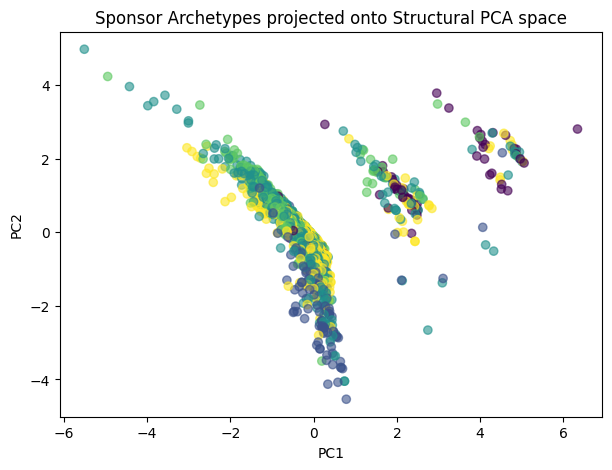

In [ ]:
# Create scatter plot of medicines in PCA space colored by MAH cluster
plt.figure(figsize=(7,5))

plt.scatter(
    df_m3["pc1"],
    df_m3["pc2"],
    c=df_m3["cluster_mah_k5"],
    alpha=0.6
)

plt.title("Sponsor Archetypes projected onto Structural PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Observation:**
Sponsor archetypes exhibit distinct distributions across structural clusters and stability regimes.

**Business Interpretation:**
Organizational structure and sponsor characteristics influence regulatory trajectories and risk profiles.

**Implication for Modeling:**
Sponsor archetypes represent an organizational structural dimension of regulatory risk. Integrating sponsor archetypes with medicine-level clustering enables multi-level structural analysis.

###9.4 Synergy D: AM-missing medicines (core integrated finding)

In [ ]:
# Compute Additional Monitoring (AM) rate for each structural cluster
cluster_am_rate = df_m3.groupby("cluster_struct_k4")["am_flag"].mean()
thr = np.quantile(cluster_am_rate.values, 0.75)
am_heavy_clusters = cluster_am_rate[cluster_am_rate >= thr].index.tolist()

# Select medicines in AM-heavy clusters that do not have AM assigned
am_missing = df_m3[
    (df_m3["cluster_struct_k4"].isin(am_heavy_clusters)) &
    (df_m3["am_flag"] == 0)
].copy()

print("AM-heavy clusters:", am_heavy_clusters)
print("AM-missing count:", am_missing.shape[0])
print("AM-missing withdrawn rate:", round(float(am_missing["is_withdrawn"].mean()), 3))
print("AM-missing median revisions:", float(am_missing["revision_count"].median()))

am_missing[[
    "Medicine name","Authorisation status","revision_count","decision_year",
    "cluster_struct_k4","am_flag","is_withdrawn"
]].head(25)

AM-heavy clusters: [2]
AM-missing count: 4
AM-missing withdrawn rate: 0.75
AM-missing median revisions: 1.0


,Medicine name,Authorisation status,revision_count,decision_year,cluster_struct_k4,am_flag,is_withdrawn
5,Caprelsa,Authorised,24.0,2023.0,2,0,0
1609,Zalmoxis,Withdrawn,1.0,2018.0,2,0,1
1878,Arepanrix,Withdrawn,1.0,2010.0,2,0,1
1883,Humenza,Withdrawn,0.0,2011.0,2,0,1


In [ ]:
# Check if stability cluster labels exist before analysis
if "cluster_stability_k2" in df_m3.columns:
    m = am_missing["cluster_stability_k2"].notna()
    print("AM-missing by stability regime:")
    print(am_missing.loc[m].groupby("cluster_stability_k2").size())

AM-missing by stability regime:
cluster_stability_k2
0.0    1
1.0    3
dtype: int64


**Observation:**
Structurally high-risk medicines lacking Additional Monitoring designation exist within high-risk structural clusters.

**Business Interpretation:**
Additional Monitoring assignment may not fully align with structural regulatory risk.

**Implication for Modeling:**
Structural clustering enables identification of potential regulatory monitoring inconsistencies. This directly supports the project’s core hypothesis regarding structural consistency of pharmacovigilance prioritization.

##10. Failed Synergy

###10.1 Direct integration of semantic embeddings into structural clustering

**Observation:**
Integrating high-dimensional TF-IDF semantic features directly into structural clustering increased dimensionality but did not improve cluster separability or interpretability.

**Business Interpretation:**
While therapeutic similarity contributes to regulatory structure, regulatory risk is more strongly driven by regulatory pathway complexity, revision intensity, and structural regulatory characteristics rather than semantic similarity alone.

**Implication for Modeling:**
This integration attempt was deprioritized in favor of combining semantic similarity through visualization and interpretation rather than direct clustering input. Structural clustering based on regulatory features provides a more stable and interpretable representation of regulatory risk regimes.

Code section 6.7